## 01. DecisionTreeRegressor 개념

### 01-00. 이 모델을 배우는 이유와 활용 장면
- 배우는 이유
  - 결정트리는 분류뿐 아니라 숫자 예측에도 사용할 수 있음.
  - 회귀 트리는 leaf에 모인 target 평균으로 예측하므로 선형 회귀와 다른 방식의 숫자 예측을 이해하기 좋음.
  - 비선형 관계나 구간별 패턴을 조건 분기로 표현할 수 있음.

- 사용하는 장면
  - 주택 가격, 매출, 수요량, 중고차 가격, 에너지 사용량 같은 연속형 값 예측.
  - 값이 구간별로 달라지는 문제.
  - RandomForestRegressor, GradientBoostingRegressor 같은 회귀 앙상블 모델의 기초.

### 01-01. 결정트리 회귀란?
- 결정트리 구조를 사용해 숫자 값을 예측하는 모델
- 데이터를 조건에 따라 나누는 방식은 분류 트리와 동일
- 차이는 leaf node에서 내는 최종 결과

### 01-02. 분류 트리와 회귀 트리 비교
- 분류 트리
  - target이 클래스
  - 예: red/white, setosa/versicolor/virginica
  - leaf에서 다수 클래스를 예측

- 회귀 트리
  - target이 연속형 숫자
  - 예: 주택 가격, 매출, 온도
  - leaf에서 평균값을 예측

### 01-03. 예측 과정
1. 입력 데이터가 root node에서 시작
2. 각 node의 조건에 따라 왼쪽/오른쪽으로 이동
3. leaf node에 도착
4. 해당 leaf에 모인 훈련 데이터 target의 평균값을 예측값으로 반환

### 01-04. 장점과 단점
- 장점
  - 비선형 관계를 조건 분기로 표현 가능
  - 결과를 트리 그림으로 해석 가능
  - feature 스케일 차이에 비교적 둔감

- 단점
  - 트리가 깊어지면 과적합되기 쉬움
  - 데이터가 조금 바뀌면 트리 구조가 달라질 수 있음
  - 단일 트리보다 앙상블 모델에서 더 안정적인 경우가 많음

## 02. 실습 환경 준비

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, root_mean_squared_error


## 03. 캘리포니아 주택가격 예측
- 사용 데이터: California Housing 데이터
- 목표: 지역 특성을 이용해 주택 가격을 예측
- target: `MedHouseVal`
  - 중간 주택 가격
  - 회귀 문제이므로 연속형 숫자 예측

In [2]:
# fetch_california_housing()은 외부 서버 다운로드가 필요해 403 오류가 발생할 수 있음.
# 같은 데이터를 data/california_housing.csv로 저장해 두고 로컬 파일로 읽음.
housing_df = pd.read_csv('data/california_housing.csv')

# MedHouseVal은 예측할 주택 가격이고, 나머지 컬럼은 입력 feature임.
housing_feature_names = housing_df.drop(columns='MedHouseVal').columns.tolist()
X = housing_df[housing_feature_names]
y = housing_df['MedHouseVal']

housing_df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 04. 학습/평가 데이터 분리
- 학습 데이터: 모델이 규칙을 배우는 데이터
- 평가 데이터: 새 데이터에도 잘 맞는지 확인하는 데이터
- `test_size=0.2`: 전체 데이터 중 20%를 평가용으로 사용

In [3]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
    ))

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


## 05. 결정트리 회귀 모델 학습

### 05-01. `DecisionTreeRegressor`
- 조건 분기로 데이터를 나눈 뒤 leaf node의 평균값으로 숫자를 예측함.
- `criterion='squared_error'`는 평균제곱오차를 줄이는 방향으로 분기 기준을 선택함.
- `max_depth`는 트리 최대 깊이를 제한하는 하이퍼파라미터임.

### 05-02. 평가 지표
- `R²`: 모델이 target 변동을 얼마나 설명하는지 나타내는 지표. `1`에 가까울수록 좋음.
- `MSE`: 오차를 제곱해 평균낸 값. 값이 작을수록 좋고 큰 오차에 민감함.
- `RMSE`: MSE에 루트를 씌운 값. target과 같은 단위라 MSE보다 해석이 쉬움.

### 05-03. 확인할 내용
- `max_depth=None`: 트리가 제한 없이 깊어질 수 있음.
- `max_depth=3`: 단순한 트리.
- `max_depth=8`: 복잡도와 성능의 균형을 보는 예시.


In [4]:
results = []
models = {}

for depth in [None, 3, 8]:
    model = DecisionTreeRegressor(
        random_state=42,
        max_depth=depth,
        criterion='squared_error',
    )

    model.fit(X_train, y_train)
    models[depth] = model # {None:model, 3:model, 8:model}

    y_train_pred = model.predict(X_train) # 학습셋
    y_test_pred = model.predict(X_test)   # 평가셋

    results.append({
        'max_depth': 'None' if depth is None else depth,
        'train_R2': model.score(X_train, y_train),
        'test_R2': model.score(X_test, y_test),
        'train_MSE': mean_squared_error(y_train, y_train_pred),
        'test_MSE': mean_squared_error(y_test, y_test_pred),
        'train_RMSE': root_mean_squared_error(y_train, y_train_pred),
        'test_RMSE': root_mean_squared_error(y_test, y_test_pred),
        'tree_depth': model.get_depth(),
        'leaf_count': model.get_n_leaves()
    })

result_df = pd.DataFrame(results)
display(result_df)


dt_reg = models[8] # 예측 및 시각화 진행 시 사용할 모델 선정

,max_depth,train_R2,test_R2,train_MSE,test_MSE,train_RMSE,test_RMSE,tree_depth,leaf_count
0,None,1.000000,0.622823,9.105916e-32,0.494256,3.017601e-16,0.703033,34,15860
1,3,0.537898,0.509763,6.177279e-01,0.642411,7.859567e-01,0.801505,3,8
2,8,0.760173,0.677928,3.205950e-01,0.422045,5.662111e-01,0.649650,8,243


## 06. 새로운 지역 데이터 예측

### 06-01. 왜 새 데이터를 예측해보는가?
- 회귀 모델의 최종 목적은 학습 데이터 점수를 확인하는 것에서 끝나지 않음.
- 학습한 모델에 새로운 입력 feature를 넣고 target 숫자를 예측하는 것이 실제 사용 흐름임.
- California Housing의 target `MedHouseVal`은 10만 달러 단위의 주택 가격임.

### 06-02. 예측할 때 주의할 점
- 새 데이터도 학습 때 사용한 feature와 같은 컬럼을 가져야 함.
- 컬럼 순서도 학습 데이터와 같아야 안전함.
- 이 노트북은 스케일링하지 않았으므로 원래 단위의 값을 그대로 넣음.


In [5]:
#학습한 결정트리 회귀 모델에 새로운 지역 데이터를 넣어 주택 가격을 예측함.

# X_train의 중앙값을 기준으로 일반적인 지역 샘플을 하나 만듦.
# 중앙값을 사용하면 너무 극단적인 값을 직접 만드는 일을 피할 수 있음.
base_sample = X_train.median()

# 예측용 샘플 2개를 만듦.
# MedInc: 중간 소득, HouseAge: 주택 연식, AveRooms: 평균 방 수
# Latitude/Longitude는 지역 위치 정보이므로 학습 데이터 범위 안의 값을 사용함.
new_housing_samples = pd.DataFrame([
    base_sample,
    base_sample,
])

new_housing_samples.index = ['sample_1', 'sample_2']

# sample_1: 평균적인 지역에 가까운 예시
new_housing_samples.loc['sample_1', 'MedInc'] = 4.0
new_housing_samples.loc['sample_1', 'HouseAge'] = 25
new_housing_samples.loc['sample_1', 'AveRooms'] = 5.5

# sample_2: 소득과 평균 방 수가 더 높은 지역 예시
new_housing_samples.loc['sample_2', 'MedInc'] = 8.0
new_housing_samples.loc['sample_2', 'HouseAge'] = 20
new_housing_samples.loc['sample_2', 'AveRooms'] = 6.5

# 학습 때 사용한 feature 순서와 동일하게 컬럼을 정렬함.
new_housing_samples = new_housing_samples[housing_feature_names]

display(new_housing_samples)

# dt_reg를 이용한 예측
predictions = dt_reg.predict(new_housing_samples)

prediction_df = new_housing_samples.copy()
prediction_df['pred_MedHouseVal'] = predictions

# MedHouseVal은 10만 달러 단위이므로 사람이 보기 쉽게 달러 단위로도 변환함.
prediction_df['pred_price_dollar'] = prediction_df['pred_MedHouseVal'] * 100000

display(prediction_df[['MedInc', 'HouseAge', 'AveRooms', 'pred_MedHouseVal', 'pred_price_dollar']])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
sample_1,4.0,25.0,5.5,1.049286,1167.0,2.81724,34.26,-118.51
sample_2,8.0,20.0,6.5,1.049286,1167.0,2.81724,34.26,-118.51


,MedInc,HouseAge,AveRooms,pred_MedHouseVal,pred_price_dollar
sample_1,4.0,25.0,5.5,2.037094,203709.367041
sample_2,8.0,20.0,6.5,3.643616,364361.602564


## 07. 회귀 트리 시각화

### 07-01. 시각화 목적
- 회귀 트리가 어떤 조건으로 주택 데이터를 나누는지 확인함.
- 상위 몇 단계만 봐도 모델이 중요하게 보는 feature를 파악할 수 있음.
- `max_depth=2`는 그림을 읽기 쉽게 상위 구조만 보여주기 위한 설정임.

### 07-02. 트리 그림 읽는 법
- 조건: 데이터를 왼쪽/오른쪽으로 나누는 기준
- `squared_error`: 현재 노드의 평균제곱오차
- `samples`: 현재 노드에 들어온 데이터 개수
- `value`: 해당 노드의 평균 target 값

### 07-03. 분류 트리와 다른 점
- 분류 트리의 `value`: 클래스별 개수
- 회귀 트리의 `value`: 예측에 사용할 평균 숫자값

### 07-04. 기준값 해석
- 이 노트북은 스케일링하지 않은 feature로 회귀 트리를 학습함.
- 따라서 트리 그림의 조건값은 원래 California Housing 데이터 단위로 해석할 수 있음.


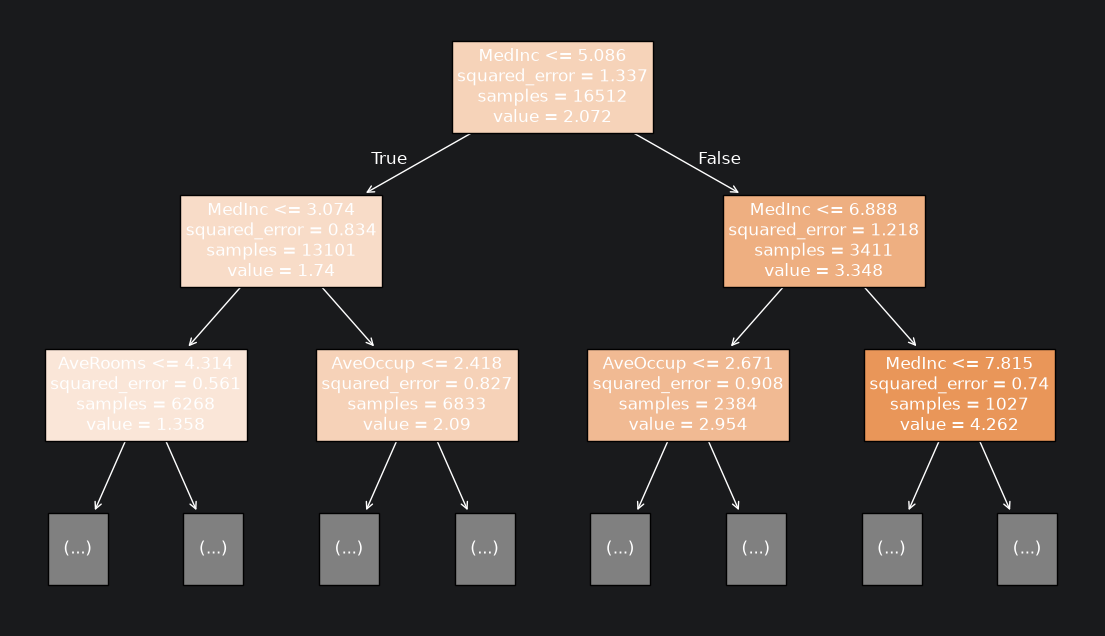

In [6]:
plt.figure(figsize=(14, 8))
plot_tree(
    dt_reg,
    filled=True,
    feature_names=housing_feature_names,
    max_depth=2,
    fontsize=12,
)

plt.show()